In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/raw/demand.csv")
df["Date"] = pd.to_datetime(df["Date"])

df["Order_Demand"] = (
    df["Order_Demand"]
    .astype(str)
    .str.replace(",","",regex = False)
)

df["Order_Demand"] = pd.to_numeric(df["Order_Demand"], errors="coerce")

In [3]:
#identifying high demnad product

product_avg = (
    df.groupby("Product_Code")["Order_Demand"]
    .mean()
    .sort_values(ascending = False)
)

high_demand = product_avg.index[0]
print(high_demand)

Product_1245


In [4]:
#Aggregate daily demand for this product

daily_series = (df[df["Product_Code"] == high_demand]
               .groupby("Date",as_index = False)["Order_Demand"]
                .sum()
                .sort_values("Date")
               )
daily_series.head()

,Date,Order_Demand
0,2011-12-28,900000.0
1,2012-01-09,10000.0
2,2012-01-11,75000.0
3,2012-01-16,20000.0
4,2012-01-18,402000.0


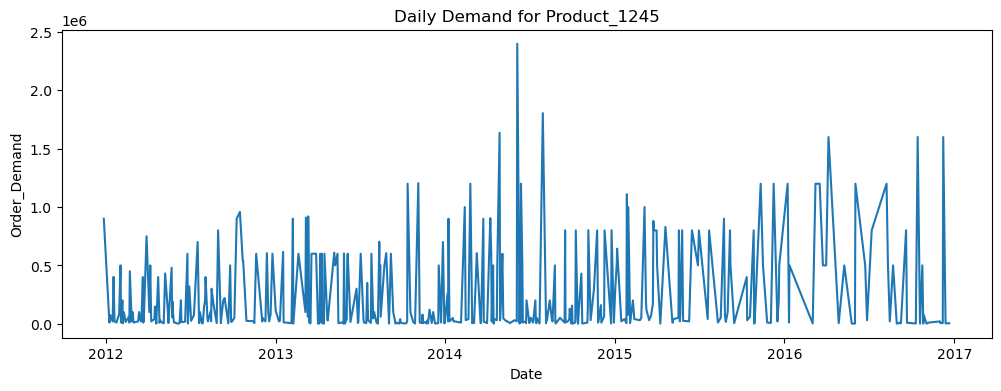

In [5]:
plt.figure(figsize = (12,4))
plt.plot(daily_series["Date"],daily_series["Order_Demand"])
plt.title(f"Daily Demand for {high_demand}")
plt.xlabel("Date")
plt.ylabel("Order_Demand")
plt.show()

In [6]:
#train test split

split_index = int(len(daily_series) * 0.8)

train = daily_series.iloc[:split_index]
test = daily_series.iloc[split_index:]

print("Train Size: ", len(train))
print("Test Size: ", len(test))

Train Size:  332
Test Size:  83


[]

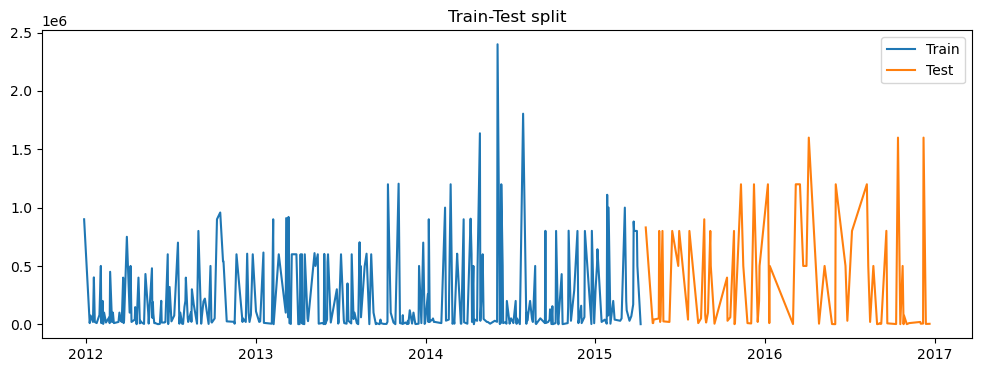

In [7]:
plt.figure(figsize = (12,4))
plt.plot(train["Date"], train["Order_Demand"], label = "Train")
plt.plot(test["Date"], test["Order_Demand"], label = "Test")
plt.legend()
plt.title("Train-Test split")
plt.plot()

In [11]:
#naive forecast

naive_prediction = test["Order_Demand"].shift(1)
naive_prediction.iloc[0] = train["Order_Demand"].iloc[-1]
naive_prediction.head()

332      1000.0
333    830000.0
334     10000.0
335     10000.0
336     40000.0
Name: Order_Demand, dtype: float64

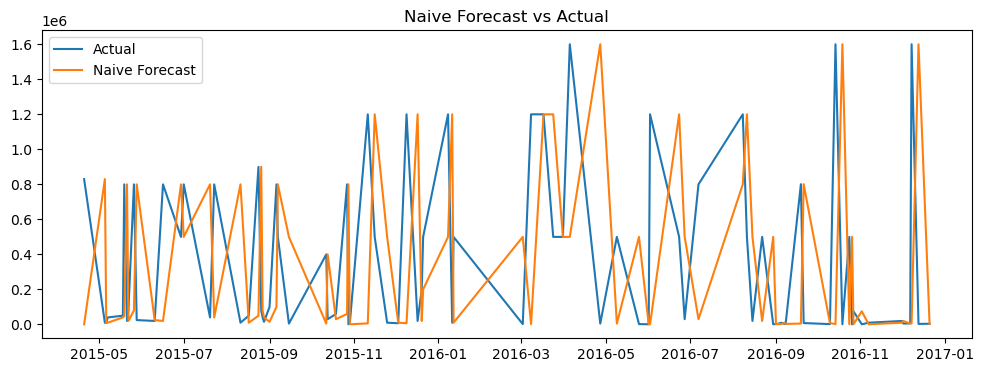

In [13]:
plt.figure(figsize = (12,4))
plt.plot(test["Date"],test["Order_Demand"], label = "Actual")
plt.plot(test["Date"],naive_prediction, label = "Naive Forecast")
plt.title("Naive Forecast vs Actual")
plt.legend()
plt.show()